# Practical session 2 - Practise with classic libraries

Students (pair):
- [Henry Fernandes--Strag](https://github.com/hfstrag)
- [Alexandre Torres--Leguet]([link](https://github.com/alxndrTL))

GitHub project where we collaborate: https://github.com/alxndrTL/python_sdia

```
conda create --name=lab2 --file=requirement.txt
conda activate lab2
# do not forget to deactivate the environment if needed
# you can remove the environment once you are done
conda env remove --name=lab2
```

**Useful references for this lab**:

[1] `numpy`: [lecture notes (1.4.1-1.4.2)](https://scipy-lectures.org/intro/numpy/index.html) and [documentation](https://numpy.org/doc/stable/)

[2] `pandas`: [documentation](https://pandas.pydata.org/docs/getting_started/index.html), [quick tutorial](https://pandas.pydata.org/pandas-docs/version/0.15/10min.html)

[3] `matplotlib`: [lecture notes (1.5)](https://scipy-lectures.org/intro/matplotlib/index.html) and [documentation](https://matplotlib.org/)

[4] `h5py`: [quick start guide](http://docs.h5py.org/en/stable/quick.html#quick)

## <a name="content">Contents</a>
- [Exercise 1: Computing basic statistics](#ex1)
- [Exercise 2: Random variables and histograms](#ex2)
- [Exercise 3: Discrete isotropic total variation](#ex3)
---

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
from IPython.display import display

---
## <a name="ex1">Exercise 1: Random variables and histograms</a>

In this exercise, we are interested in generating samples from the Gamma distribution $\mathcal{G}(\alpha,\beta)$, of probability density function (pdf)

\begin{equation}
    p(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1} \exp(-\beta x) \mathbb{1}_{\mathbb{R}_+^*}(x),
\end{equation}

and displaying their histogram. In the following, we consider $(\alpha, \beta) = (9, 2)$.

1\. Set the random seed to a fixed value for reproducibility, and biefly check your instruction works as intended.
> Hint: you may take a look at the following pages: [random module](https://numpy.org/doc/stable/reference/random/index.html?highlight=random#module-numpy.random), [random generator](https://numpy.org/doc/stable/reference/random/generator.html).

**Answer**:

In [3]:
np.random.seed(0)

In [4]:
# on vérifie que la seed est bien fixée :
for _ in range(5):
    np.random.seed(0)
    print(np.random.randint(0, 10))

5
5
5
5
5


In [5]:
# on a bien 5 fois le même nombre aléatoire, ce qui est attendu car on reset la seed à chaque fois

2\. Generate $\approx 10^5$ samples in a vector. Save the vector in a file, `samples.hdf5` or `samples.npy`.
> Warning / hint: 
> - take a careful look at the [documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.gamma.html?highlight=gamma#numpy.random.gamma) (multiple conventions exist for the definition of the pdf underlying the distribution...);
> - to save data in a `npy` file, take a look at the example reported in the [Numpy documentation](https://numpy.org/doc/stable/reference/generated/numpy.save.html);
> - to save data in a `.h5` file, take a quick look at the [documentation here](https://docs.h5py.org/en/stable/quick.html#quick).

**Answer**:

In [6]:
alpha, beta = 9, 2
X = np.random.gamma(shape=alpha, scale=1/beta, size=(10**5, 1))
# par identification dans la formule donnée et celle de la doc numpy:
# shape = alpha
# scale = 1/beta

# enregistrement
np.save("gamma.npy", X)

3\. Estimate an histogram of this distribution for a well chosen set of bins, and display it.
> Warnings: 
> - make sure the [histogram](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html?highlight=hist#matplotlib.pyplot.hist) corresponds to a probability density function (pdf);
> - do not forget to include a proper title with names for the axes.

**Answer**:

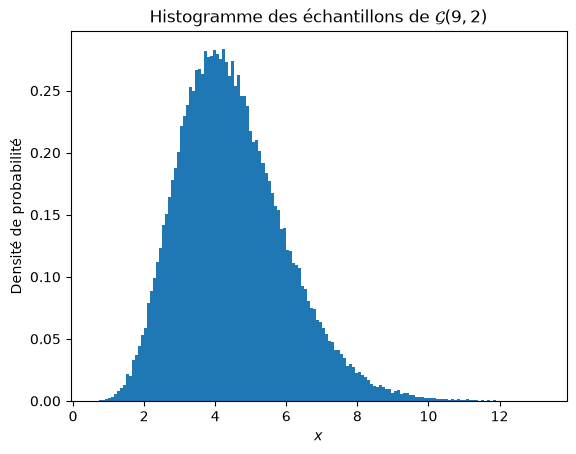

150


In [7]:
plt.figure()
# au lieu de spécifier un nombre de bins, on utilise le paramètre "fd" qui utilise la règle de Freedman-Diaconis 
# pour déterminer le nombre de bins optimal en fonction de la taille et de la dispersion des données
# on utilise aussi density=True pour normaliser l'histogramme et obtenir une densité de probabilité
counts, edges, _ = plt.hist(X, bins="fd", density=True)
plt.xlabel(r"$x$") # le titre des axes acceptent du MathJax / un équivalent de latex
plt.ylabel("Densité de probabilité")
plt.title(r"Histogramme des échantillons de $\mathcal{G}(9, 2)$")
plt.show()

# on peut récuperer le nombre de bins utilisés: 180 
print(len(edges)-1)

4\. Overlay the probability density function on the histogram and compare these in a few words. Save the resulting picture in `.png` format.
> Hint: 
> - take a look at the `scipy` [documentation](https://docs.scipy.org/doc/scipy/reference/stats.html) to avoid implementing the pdf from scratch;
> - return the bins in which the histogram is computed, and evaluate the pdf on those points.

**Answer**:

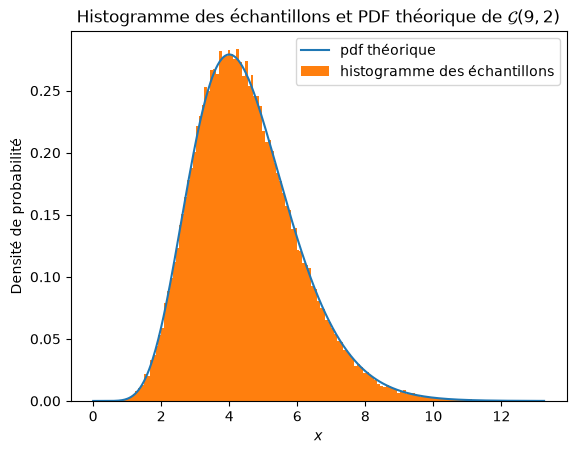

In [8]:
plt.figure()
x = np.linspace(0, X.max(), 500)
plt.plot(x, scipy.stats.gamma.pdf(x, a=alpha, scale=1/beta), label="pdf théorique")
plt.hist(X, bins="fd", density=True, label="histogramme des échantillons")
plt.xlabel(r"$x$")
plt.ylabel("Densité de probabilité")
plt.title(r"Histogramme des échantillons et PDF théorique de $\mathcal{G}(9, 2)$")
plt.legend()
plt.savefig("histogramme_pdf.png", dpi=600)
plt.show()

---
## <a name="ex2">Exercise 2: Basic statistics with `pandas`</a>

In this second exercise, we focus on computing basic statistics, and applying linear regression to a small data set. These data are gathered in the following table, which gives the infant mortality (`X`) and the gross national product per inhabitant (`Y`) of 12 european countries :

| `X` | 190 | 128 | 180 | 212 | 56 | 192 | 68 | 98 | 110 | 197 | 181 | 233 |
|-----|-----|-----|-----|----|-----|----|----|-----|-----|-----|-----|-----|
| `Y` |  24 |  28 |  24 | 19 |  37 | 22 | 34 |  25 |  36 |  24 |  20 |  18 |

1\. For `X `and `Y`, compute the median, mean, variance and standard deviation. The data points have already been entered into a `.csv` file stored in `data/data.csv`.
> Hint: 
> - you can directly use `pandas` to load the data into a `DataFrame` ([`pd.read_csv`](https://pandas.pydata.org/docs/reference/frame.html));
> - take a look at the built-in operations available for `DataFrame` objects ([documentation](https://pandas.pydata.org/docs/reference/frame.html));
> - to display a `DataFrame` `f`:
> ```python 
> from IPython.display import display
> display(df)
> ```
> - sort the `DataFrame` with respect to the value of `X` (see [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html#pandas.DataFrame.sort_values)) This will be useful for question 3.

**Answer**:

In [9]:
df = pd.read_csv("data/data.csv")
display(df)

,X,Y
0,190,24
1,128,28
2,180,24
3,212,19
4,56,37
5,192,22
6,68,34
7,98,25
8,110,36
9,197,24


In [10]:
df.describe()

,X,Y
count,12.00000,12.000000
mean,153.75000,25.916667
std,59.04255,6.515134
min,56.00000,18.000000
25%,107.00000,21.500000
50%,180.50000,24.000000
75%,193.25000,29.500000
max,233.00000,37.000000


In [11]:
# d'après le .describe() :
# pour X, la médianne est 24, la moyenne 25.92, la variance est 42.51 et l'écart-type est 6.52
# pour Y, la médianne est 180.5, la moyenne 153.75, la variance 3481, et l'écart-type 59.04

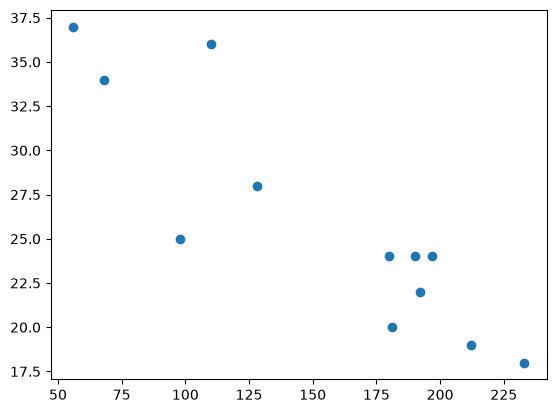

In [12]:
# on peut aussi visualiser Y en fonction de X
plt.plot(df["X"], df["Y"], "o")

In [13]:
# une droite semble bien prédire Y en fonction de X, la régression linéaire semble pertinente

In [14]:
# on trie le dataframe selon X, dans l'ordre croissant
df = df.sort_values("X")
display(df)

,X,Y
4,56,37
6,68,34
7,98,25
8,110,36
1,128,28
2,180,24
10,181,20
0,190,24
5,192,22
9,197,24


2\. Give the equation of the regression line of `Y` as a function of `X`.
> Hint: 
> - take a look at the functionalities available in `numpy` (e.g., `np.polyfit` and `np.polyval`);
> - if needed, note that you can retrieve the data from the resulting `pandas` `DataFrame` with the `to_numpy()` method.

**Answer**:

In [15]:
a, b = np.polyfit(df["X"].to_numpy(), df["Y"].to_numpy(), deg=1) # deg=1 pour se limiter à une droite

print(f"Y = {a:.4f} X + {b:.4f}")

Y = -0.0982 X + 41.0095


In [16]:
# par rapport à la visualisation précédente, on a bien une pente négative et une ordonnée à l'origine d'environ 40
# cela semble correct

3\. Display the cloud of points and the regression line $Y = f(X)$ on the same figure. Save the figure in `.png` format.

**Answer**:

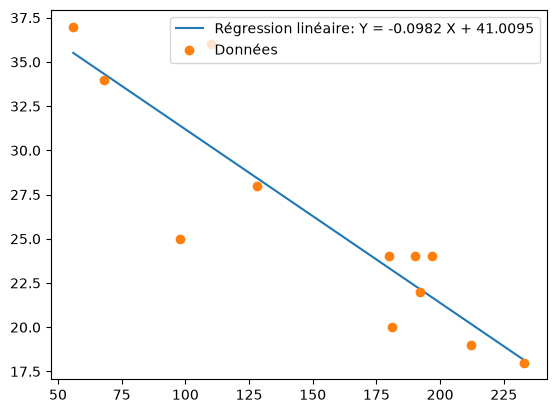

In [17]:
# on construit l'espace d'entrée x avec un linspace
x = np.linspace(df["X"].min(), df["X"].max(), 100)
# puis les prédictions "y_hat" du modèle via a*x+b (calcul vectoriel, x et y sont des vecteurs)
y_hat = a*x + b
plt.plot(x, y_hat, label=f"Régression linéaire: Y = {a:.4f} X + {b:.4f}")
plt.plot(df["X"], df["Y"], "o", label="Données")
plt.legend()
plt.show()

---
## <a name="ex3">Exercise 3: Discrete isotropic total variation</a>

This exercise is devoted to the computation of the discrete isotropic total variation (TV) of an input matrix $\mathbf{X} = [\mathbf{x}_n]_{1 \leq n \leq N} \in\mathbb{C}^{M \times N}$, which is particularly useful in Bayesian inference (e.g., for inverse problems) to promote piece-wise smooth solutions. The TV is defined as

\begin{equation*}
    \text{TV}(\mathbf{X}) = \Vert D(\mathbf{X}) \Vert_{1,2} = \sum_{m=1}^M \sum_{n=1}^N \sqrt{[\mathbf{XD}_h]^2_{m,n} + [\mathbf{D}_v\mathbf{X}]^2_{m,n}},
\end{equation*}

where $[\mathbf{Z}]_{m,n}$ denotes the elements in position $(m,n)$ of the matrix $\mathbf{Z}$,

\begin{align*}
    D(X) &= (\mathbf{XD}_h, \mathbf{D}_v\mathbf{X}) \in \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \\
    %
    \mathbf{XD}_h &= [\mathbf{x}_2-\mathbf{x}_1, \dotsc, \mathbf{x}_N-\mathbf{x}_{N-1}, \mathbf{0}_M] \in \mathbb{C}^{M\times N} \\
    %
    \mathbf{D}_v\mathbf{X} &= [\tilde{\mathbf{x}}_2^T-\tilde{\mathbf{x}}^T_1, \dotsc, \tilde{\mathbf{x}}^T_M-\tilde{\mathbf{x}}^T_{M-1}, \mathbf{0}_N]^T \in \mathbb{C}^{M\times N},
\end{align*}

$\mathbf{x}_n \in \mathbb{C}^{M}$ is the $n$-th column of $\mathbf{X}$, and $\tilde{\mathbf{x}}_m \in \mathbb{C}^{1\times N}$ is the $m$-th row of $\mathbf{X}$. 
The linear operator $D: \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} $ is the discrete gradient operator. The adjoint of $D$, $D^*: \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N}$, is given by

\begin{align*}
    (\forall \mathbf{Y} = (\mathbf{Y}_h,\mathbf{Y}_v)), \quad D^*(\mathbf{Y}) &= \mathbf{Y}_h\mathbf{D}^*_h + \mathbf{D}^*_v\mathbf{Y}_v \\
    %
    \mathbf{Y}_h\mathbf{D}^*_h &= \big[-\mathbf{y}_{h,1},- [\mathbf{y}_{h,n}-\mathbf{y}_{h,n-1}]_{2 \leq n \leq N-1}, \mathbf{y}_{h, N-1} \big] \\
    %
    \mathbf{D}^*_v\mathbf{Y}_v &= \big[-\tilde{\mathbf{y}}_{v,1}^T,- [\tilde{\mathbf{y}}_{v,m}^T-\tilde{\mathbf{y}}^T_{v,m-1}]_{2 \leq m \leq M-1}, \tilde{\mathbf{y}}^T_{v, M-1} \big]^T
\end{align*}

where $\mathbf{y}_{h,n}$ is the $n$-th column of $\mathbf{Y}_h$, and $\tilde{\mathbf{x}}_{v,m}$ is the $m$-th row of $\mathbf{Y}_v$.

1\. Using `numpy`, implement a function `gradient2D` to compute the 2D discrete gradient operator $D$ applied to a matrix $\mathbf{X}\in\mathbb{C}^{M \times N}$ (no for loops!). Trigger an error message whenever the input array has more than 2 dimensions. If not clear from the implementation, add a few short comments to explain your code.

> Hint: 
> - to trigger an error, you can for instance use an `assert` statement, or raise an [exception (e.g., `AssertionError`)](https://docs.python.org/3/library/exceptions.html);
> - only a few operations are needed: computing vertical differences, horizontal differences, and possibly a concatenation of matrices into a single tensor (= n-dimensional array);
> - possibly useful functions: `np.diff`, `np.c_`, `np.r_` (or `np.concatenate`). 

**Answer**:

In [18]:
def gradient2D(X):
    """Calcule le gradient discret 2D d'une matrice.
 
    Paramètres
    ----------
    X : numpy.ndarray, de taille (M, N)
        Matrice d'entrée
 
    Retour
    ------
    numpy.ndarray, de taille (M, N, 2)
        [:, :, 0] : différences horizontales X D_h,
        [:, :, 1] : différences verticales D_v X.
        Les différences valent 0 sur la dernière colonne / dernière ligne.
 
    Erreurs
    -------
    AssertionError
        Si X n'est pas un tableau à 2 dimensions.
    """

    assert X.ndim == 2, "gradient2D attend une matrice 2D"
 
    # differences horizontales (x[m, n+1] - x[m, n]) avec np.diff selon axis=1
    diff_horizontales = np.diff(X, axis=1) # renvoie une matrice (M, N-1)
    zeros = np.zeros((X.shape[0], 1)) # on ajoute une colonne de zéros pour revenir à (M, N)
    Dh = np.c_[diff_horizontales, zeros]

    # differences verticales (x[m+1, n] - x[m, n]) avec np.diff selon axis=0
    diff_verticales = np.diff(X, axis=0) # matrice (M-1, N)
    zeros = np.zeros((1, X.shape[1])) # on ajoute une ligne de zéros pour revenir à (M, N)
    Dv = np.r_[diff_verticales, zeros]
 
    return np.stack((Dh, Dv), axis=-1) # (M, N, 2)

# test
X = np.array([[1, 2], [3, 4], [5, 6]])
G = gradient2D(X)
print(G[:, :, 0])
print(G[:, :, 1])

[[1. 0.]
 [1. 0.]
 [1. 0.]]
[[2. 2.]
 [2. 2.]
 [0. 0.]]


In [19]:
# pour la matrice X testée :
# les différences horizontales valent bien 1 (2-1, 4-3, 6-5)
# les différences verticales valent bien 2 (3-1, 4-2, 5-3, 6-4)

2\. Implement a unit-test to validate the behaviour of the `gradient2D` function. For instance, you can check the format of the output, and test the result when the function is evaluated on a constant matrix (for both a square and a non-square input matrix). Run the unit-test from the present Jupyter notebook.

**Answer**:

In [20]:
# on a ré-ecrit la fonction gradient2D dans src/lab2.py
# on a aussi écrit un fichier de test dans tests/test_lab2.py qui implémente les différents tests unitaires
# puis on lance :
!python -m pytest -q tests/test_lab2.py

............                                                 [100%]
12 passed, 12 subtests passed in 0.05s


In [21]:
# les 4 tests passent bien:
# - la sortie doit être de taille (M, N, 2), pour une matrice carrée et non carrée
# - le gradient d'une matrice constante doit être nul partout
# - rampe X[m, n] = N*m + n : différences horizontales = 1, verticales = N (similaire au test précédent avec X)
# - une entrée à 3 dimensions doit déclencher une AssertionError

3\. Document the function `gradient2D` with an appropriate docstring (see Lab 1).

**Answer**:

In [22]:
# cf la fonction complète précédente (question 1)

4\. Using 1., define a function `tv` to compute $\text{TV}(\mathbf{X})$, $\mathbf{X}\in\mathbb{C}^{M \times N}$. Write a unit-test and document your function.

**Answer**:

In [23]:
def tv(X):
    """Calcule la variation totale (TV) isotrope discrète d'une matrice.

    Paramètres
    ----------
    X : numpy.ndarray, de taille (M, N)
        Matrice d'entrée

    Retour
    ------
    float
        Variation totale de X (réel positif ou nul).

    Erreurs
    -------
    AssertionError
        Si X n'est pas un tableau à 2 dimensions (levée par gradient2D).

    Notes
    -----
    Pour une matrice complexe, on utilise le module au carré |z|^2
    """

    assert X.ndim == 2, "tv attend une matrice 2D"

    G = gradient2D(X) # taille (M, N, 2)

    # norme euclidienne selon le dernier axe, puis somme sur tous les coefs
    # on retrouve bien TV(X) = somme_(m,n) de sqrt(|[X D_h]_{m,n}|^2 + |[D_v X]_{m,n}|^2)
    return np.sum(np.linalg.norm(G, axis=-1))

In [24]:
# test avec la matrice suivante :
X = np.array([[0, 3], [4, 3]])
print(tv(X))

6.0


In [25]:
# avec :
G = gradient2D(X)
print(G[:, :, 0]) # différences horizontales
print(G[:, :, 1]) # différences verticales

[[ 3.  0.]
 [-1.  0.]]
[[4. 0.]
 [0. 0.]]


In [26]:
# on a bien : TV(X) = sqrt(3^2 + 4^2) + 0 + sqrt(-1^2) + 0 = 6

In [27]:
# on implémente les tests unitaires dans tests/test_lab2.py et on lance :
!python -m pytest -q tests/test_lab2.py

............                                                 [100%]
12 passed, 12 subtests passed in 0.04s


5\. Implement a function `gradient2D_adjoint` to compute $D^*(\mathbf{Y})$, the adjoint of the 2D discrete gradient operator $D$ applied to $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$. Add a few short comments to explain your code whenever appropriate.

**Answer**:

In [28]:
def gradient2D_adjoint(Y):
    """Calcule l'adjoint D* du gradient discret 2D.

    Paramètres
    ----------
    Y : numpy.ndarray, de taille (M, N, 2)
        [:, :, 0] : composante horizontale Y_h,
        [:, :, 1] : composante verticale Y_v

    Retour
    ------
    numpy.ndarray, de taille (M, N)
        D*(Y) = Y_h D_h* + D_v* Y_v.

    Erreurs
    -------
    AssertionError
        Si Y n'est pas un tableau de taille (M, N, 2).
    """

    assert Y.ndim == 3 and Y.shape[2] == 2, "gradient2D_adjoint attend un tableau (M, N, 2)"

    Yh = Y[:, :, 0]
    Yv = Y[:, :, 1]

    # partie horizontale Y_h D_h*

    # on raisonne colonne par colonne, étant donné la définition de Y_h D_h* donnée en consigne:
    # - 1re colonne : -y_{h,1}
    # - colonnes 2 à N-1 : -(y_{h,n} - y_{h,n-1}), obtenues avec np.diff sur axis=1
    # - dernière colonne : y_{h,N-1}
    YhDh = np.c_[-Yh[:, :1], -np.diff(Yh[:, :-1], axis=1), Yh[:, -2:-1]]

    # partie verticale D_v* Y_v
    # similaire à précédemment mais en inversant les axes
    DvYv = np.r_[-Yv[:1, :], -np.diff(Yv[:-1, :], axis=0), Yv[-2:-1, :]]

    return YhDh + DvYv # (M, N)

In [29]:
Y = np.ones((3, 3, 2))
print(gradient2D_adjoint(Y))
# [[-2. -1.  0.]
#  [-1.  0.  1.]
#  [ 0.  1.  2.]]

[[-2. -1.  0.]
 [-1. -0.  1.]
 [ 0.  1.  2.]]


In [30]:
# Y_h et Y_v sont donc remplies de 1
# à la main, la matrice Y_h D_h* vaut : 
# -y_h,1 = - 1 pour la premiere colonne
# -(y_h,2 - y_h,1) = 0 pour la seconde colonne
# y_h,2 = 1 pour la derniere colonne

# donc :
# Y_h D_h* = [[-1, 0, 1],
#             [-1, 0, 1],
#             [-1, 0, 1]]

# de même, D_v* Y_v vaut :
# D_v* Y_v = [[-1, -1, -1],
#             [ 0,  0,  0],
#             [ 1,  1,  1]]

# la somme donne bien le résultat de gradient2D_adjoint(Y)

# on interprète le résultat comme étant la somme des contributions de chaque pixel dans l'opération de gradient 2D
# le pixel (0,0) par exemple contribute à -1 en dessous et -1 à droite, donc -2 au total
# le pixel du centre contribue +1 au dessus, -1 à droite, -1 en dessous, +1 à gauche, donc 0 au total

6\. Implement a unit-test to validate `gradient2D_adjoint`, e.g., by checking the size of the output from the function and verifying that `gradient2D_adjoint` is adjoint to `gradient2D`, i.e., for any $\mathbf{X}\in\mathbb{C}^{M \times N}$ and $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$:

\begin{equation}
    \forall \mathbf{X} \in \mathbb{C}^{M \times N}, \mathbf{Y} = (\mathbf{Y}_h, \mathbf{Y}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \;
    %
    \langle D(\mathbf{X}), \mathbf{Y} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{X}, D^*(\mathbf{Y}) \rangle_{\mathbb{C}^{M \times N}}, 
\end{equation}

where 

\begin{align}
    &\forall \mathbf{U}, \mathbf{V} \in \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N}} = \text{Tr}(\mathbf{U}^T \mathbf{V}) = \sum_{m=1}^M \sum_{n=1}^N u_{m,n}^* v_{m,n}, \\
    &\forall \mathbf{U} = (\mathbf{U}_h, \mathbf{U}_v), \mathbf{V} = (\mathbf{V}_h, \mathbf{V}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{U}_h, \mathbf{V}_h \rangle_{\mathbb{C}^{M \times N}} + \langle \mathbf{U}_v, \mathbf{V}_v \rangle_{\mathbb{C}^{M \times N}}.
\end{align}

> Hint: to verify `gradient2D_adjoint` is the adjoint of `gradient2D`, evaluate the scalar products above for randomly drawn matrices. Set the random generator to a known state for reproducibility (see [Exercise 1](#ex1)).

> `np.conj` is useful.

**Answer**:

In [31]:
# on implémente les tests unitaires dans tests/test_lab2.py et on lance :
!python -m pytest -q tests/test_lab2.py

............                                                 [100%]
12 passed, 12 subtests passed in 0.04s


[Bonus, **optional**]. Generalize the `gradient2D` to any number of dimensions ($\mathbf{X} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}$), i.e., by returning tensors obtained by computing differences along each of its dimensions.
> Hint: 
> - you may use a loops here, and/or list comprehension. Using slice objects (see [np.s_](https://numpy.org/doc/stable/reference/generated/numpy.s_.html?highlight=s_#numpy.s_) and [this page](https://stackoverflow.com/questions/24432209/python-index-an-array-using-the-colon-operator-in-an-arbitrary-dimension)) can be an interesting option.
>
> - the definition of the scalar product above can be extended to the case of tensors as follows:
\begin{equation}
    \mathbf{U}, \mathbf{V} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}} =  \sum_{n_1 = 1}^{N_1}  \sum_{n_2 = 1}^{N_2} \dotsc \sum_{n_p = 1}^{N_p} u_{n_1, n_2, \dotsc, n_p}^* v_{n_1, n_2, \dotsc, n_p}   
\end{equation}

**Answer**:

In [32]:
def gradient_generalise(X):
    """Calcule le gradient discret d'un tenseur avec un nombre quelconque de dimensions.

    Paramètres
    ----------
    X : numpy.ndarray, de taille (N1, N2, ..., Np)
        Tenseur d'entrée

    Retour
    ------
    numpy.ndarray, de taille (N1, N2, ..., Np, p)
        [..., k] : différences selon l'axe k, pour k = 0, ..., p-1.
        Les différences valent 0 au dernier indice de chaque axe.

    Exemples
    --------
    >>> gradientND(np.ones((2, 3, 4))).shape
    (2, 3, 4, 3)
    """

    # on procède comme gradient2D, mais au lieu de faire 2 np.diff, on le fait pour chaque axe

    gradients = []
    for k in range(X.ndim):
        # differences selon l'axe k
        # on utilise np.take pour récupérer le dernier élément le long de l'axe k, afin de pouvoir l'ajouter à la fin du résultat de np.diff avec append
        gradients.append(np.diff(X, axis=k, append=np.take(X, [-1], axis=k)))
    return np.stack(gradients, axis=-1)


In [33]:
X = np.arange(24).reshape(2, 3, 4)
G = gradient_generalise(X)

print(G.shape)
print(G[0, 0, 0]) # différences entre les axes 0, 1
print(G[1, 2, 3]) # différences selon le dernier axe, ie les différences horizontales

(2, 3, 4, 3)
[12  4  1]
[0 0 0]


## Documentation

Comme pour le lab 1, on utilise `sphinx`, on écrit dans le dossier `docs/source` les fichiers rst qui vont être utilisés pour la génération automatique de la documentation en HTML. On lance `cd docs && make html` pour générer la doc.

On ajoute aussi la possibilité de mettre des références dans le doc.

In [34]:
!make html -C docs

Running Sphinx v9.1.0
loading translations [fr]... done
loading pickled environment... done
building [mo]: targets for 0 po files that are out of date
writing output... 
building [html]: targets for 0 source files that are out of date
updating environment: 0 added, 0 changed, 0 removed
reading sources... 
looking for now-outdated files... none found
no targets are out of date.
preparing documents... done
copying assets... 
copying static files... 
Writing evaluated template result to /Users/alexandre/Desktop/inge/G3/python/python_sdia/Labs/Lab2/docs/_build/html/_static/basic.css
Writing evaluated template result to /Users/alexandre/Desktop/inge/G3/python/python_sdia/Labs/Lab2/docs/_build/html/_static/language_data.js
Writing evaluated template result to /Users/alexandre/Desktop/inge/G3/python/python_sdia/Labs/Lab2/docs/_build/html/_static/documentation_options.js
Writing evaluated template result to /Users/alexandre/Desktop/inge/G3/python/python_sdia/Labs/Lab2/docs/_build/html/_static/

## Reference

```bibtex
@article{condat:hal-01309685,
  TITLE = {{Discrete Total Variation: New Definition and Minimization}},
  AUTHOR = {Condat, Laurent},
  URL = {https://hal.archives-ouvertes.fr/hal-01309685},
  JOURNAL = {{SIAM Journal on Imaging Sciences}},
  PUBLISHER = {{Society for Industrial and Applied Mathematics}},
  VOLUME = {10},
  NUMBER = {3},
  PAGES = {1258--1290},
  YEAR = {2017},
  MONTH = Aug,
  DOI = {10.1137/16M1075247},
  KEYWORDS = { variational image processing ; total variation ;  finite-difference schemes ;  coarea formula},
  PDF = {https://hal.archives-ouvertes.fr/hal-01309685v3/file/Condat-newTV.pdf},
  HAL_ID = {hal-01309685},
  HAL_VERSION = {v3},
}
```
